# Modelos de Difusão com Guidance

Neste notebook, exploraremos o conceito de **Guidance** (Orientação) em modelos de difusão. Modelos de difusão incondicionais aprendem a gerar amostras realistas seguindo a distribuição dos dados de treino, mas não oferecem controle sobre *qual* classe ou característica é gerada. Para introduzir controle no processo generativo (geração condicional), utilizamos técnicas de Guidance.

Duas das principais abordagens para este problema são:
1. **Classifier Guidance (Orientação por Classificador):** Utiliza os gradientes de um classificador de imagens ruidosas externo para guiar a trajetória de amostragem incondicional.
2. **Classifier-Free Guidance (CFG - Orientação Livre de Classificador):** Treina conjuntamente um modelo de difusão de forma condicional e incondicional (através de dropout de rótulos) e interpola as duas predições durante a amostragem.

In [2]:
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [3]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo ativo: {device}")

Dispositivo ativo: cuda


## Preparação dos Dados

Para este notebook, utilizaremos o dataset **MNIST** (dígitos manuscritos de 0 a 9) de dimensão $28 \times 28$. As imagens serão normalizadas para o intervalo $[-1, 1]$. Para garantir que o treinamento seja rápido e possa ser executado em poucos minutos, selecionaremos um subconjunto de 15.000 imagens para o treino.

In [94]:
# Hiperparâmetros de dados
batch_size = 128

transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)) # Normaliza de [0, 1] para [-1, 1]
])

# Carregar MNIST e obter subconjunto
train_dataset_full = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_dataset = Subset(train_dataset_full, range(10000))
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f"Subconjunto do MNIST carregado: {len(train_dataset)} imagens.")

Subconjunto do MNIST carregado: 10000 imagens.


In [95]:
# Hiperparâmetros da difusão
n_steps = 500
beta_start = 1e-4
beta_end = 0.02

# Definição do Schedule e Coeficientes Matemáticos
betas = torch.linspace(beta_start, beta_end, n_steps).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)
alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), alphas_cumprod[:-1]], dim=0)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# Variância teórica do passo reverso (q(x_{t-1} | x_t, x_0))
posterior_variance = betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)

In [96]:
def q_sample(x_0, t, noise=None):
    """Amostra x_t a partir de x_0 no passo t."""
    noise = torch.randn_like(x_0) if noise is None else noise
    shape = (t.shape[0],) + (1,) * (x_0.ndim - 1)
    alpha_t = sqrt_alphas_cumprod[t].reshape(shape)
    sigma_t = sqrt_one_minus_alphas_cumprod[t].reshape(shape)
    return alpha_t * x_0 + sigma_t * noise

## Classifier Guidance

A orientação por classificador propõe a utilização de um classificador externo $p_\phi(y | x_t)$, previamente treinado em imagens com ruído, para guiar a amostragem de um modelo de difusão incondicional $\epsilon_\theta(x_t, t)$. Em cada passo temporal $t$, a previsão de ruído é modificada adicionando o gradiente da log-verossimilhança do classificador em relação à imagem ruidosa $x_t$:

$$\tilde{\epsilon}_\theta(x_t, t, y) = \epsilon_\theta(x_t, t) - \sqrt{1 - \bar{\alpha}_t} s \nabla_{x_t} \log p_\phi(y | x_t)$$

Onde $s \ge 0$ é a escala de guidance (*guidance scale*), $y$ é a classe alvo desejada e $\bar{\alpha}_t$ é a variância acumulada no passo $t$. O classificador recebe a imagem ruidosa $x_t$ e o passo temporal $t$, mostrando a direção de alteração ideal para aproximar $x_t$ da classe alvo.

### Arquitetura do Modelo (Difusão Incondicional)

Primeiramente, definiremos a arquitetura do **Modelo de Difusão Incondicional** (`UnconditionalUNet`). Este modelo recebe uma imagem ruidosa $x_t \in \mathbb{R}^{B \times 1 \times 28 \times 28}$ e o passo de tempo $t$, e prevê o ruído $\epsilon$ contido nela. O tempo $t$ é mapeado usando embeddings posicionais senoidais e somado aos canais ocultos.

In [97]:
# class SinusoidalPositionEmbeddings(nn.Module):
#     def __init__(self, dim):
#         super().__init__()
#         half = dim // 2
#         self.register_buffer("freq", torch.exp(-math.log(10000) * torch.arange(half) / (half - 1)))

#     def forward(self, t):
#         x = t.float()[:, None] * self.freq[None, :]
#         return torch.cat((x.sin(), x.cos()), dim=-1)

class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2

        freqs = torch.exp(
            -math.log(10000) * torch.arange(half_dim, device=device) / (half_dim - 1)
        )

        emb = time[:, None] * freqs[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=-1)

        return emb

In [98]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        self.block1 = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(groups, out_ch),
            nn.GELU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(groups, out_ch),
            nn.GELU()
        )
        self.res_conv = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch
            else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.block1(x)
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, stride=2, padding=1)

    def forward(self, x):
        return self.conv(x)

In [99]:
class UnconditionalUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=48):
        super().__init__()

        time_dim = hidden_dim * 4

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.down1 = ResBlock(hidden_dim, hidden_dim, time_dim)
        self.downsample1 = Downsample(hidden_dim)

        self.down2 = ResBlock(hidden_dim, hidden_dim * 2, time_dim)
        self.downsample2 = Downsample(hidden_dim * 2)

        self.mid1 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)
        self.mid2 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)
        self.mid3 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)

        self.upsample2 = Upsample(hidden_dim * 2)
        self.up2 = ResBlock(hidden_dim * 4, hidden_dim, time_dim)

        self.upsample1 = Upsample(hidden_dim)
        self.up1 = ResBlock(hidden_dim * 2, hidden_dim, time_dim)

        self.out = nn.Conv2d(hidden_dim, out_channels, 1)

    def forward(self, x, t):
        emb = self.time_mlp(t)

        x = self.init_conv(x)

        h1 = self.down1(x, emb)       # 32x32
        x = self.downsample1(h1)      # 16x16

        h2 = self.down2(x, emb)       # 16x16
        x = self.downsample2(h2)      # 8x8

        x = self.mid1(x, emb)
        x = self.mid2(x, emb)
        x = self.mid3(x, emb)

        x = self.upsample2(x)         # 16x16
        x = torch.cat([x, h2], dim=1)
        x = self.up2(x, emb)

        x = self.upsample1(x)         # 32x32
        x = torch.cat([x, h1], dim=1)
        x = self.up1(x, emb)

        return self.out(x)

### Arquitetura do Modelo (Classificador Ruidoso)

Definiremos agora o **Classificador de Imagens Ruidosas** (`MNISTNoiseClassifier`). Ele recebe a imagem com ruído $x_t$ e o passo temporal $t$, e produz as pontuações (logits) das 10 classes de dígitos manuscritos. É fundamental que ele seja treinado com imagens contendo diferentes níveis de ruído para que possa fornecer gradientes úteis em qualquer passo da difusão.

In [100]:
class MNISTNoiseClassifier(nn.Module):
    def __init__(self, hidden_dim=48):
        super().__init__()

        time_dim = hidden_dim * 2

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.conv = nn.Sequential(
            nn.Conv2d(1, hidden_dim, 3, stride=2, padding=1),       # 32 -> 16
            nn.GroupNorm(4, hidden_dim),
            nn.GELU(),

            nn.Conv2d(hidden_dim, hidden_dim * 2, 3, stride=2, padding=1),  # 16 -> 8
            nn.GroupNorm(8, hidden_dim * 2),
            nn.GELU(),

            nn.Conv2d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),
            nn.GroupNorm(8, hidden_dim * 2),
            nn.GELU(),

            nn.Conv2d(hidden_dim * 2, hidden_dim * 2, 3, padding=1),
            nn.GroupNorm(8, hidden_dim * 2),
            nn.GELU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2 + time_dim, hidden_dim * 2),
            nn.GELU(),
            nn.Linear(hidden_dim * 2, 10)
        )

    def forward(self, x_t, t):
        t_emb = self.time_mlp(t)
        h = self.conv(x_t).flatten(start_dim=1)
        h = torch.cat([h, t_emb], dim=1)
        return self.fc(h)

### Treinamento

O classificador será otimizado usando entropia cruzada (`nn.CrossEntropyLoss`) sobre as amostras ruidosas $x_t$ geradas em timesteps aleatórios. O modelo de difusão incondicional será otimizado usando erro quadrático médio (`nn.MSELoss`) comparando o ruído real adicionado e o ruído previsto pela rede. Utilizaremos loops de treinamento separados com `tqdm` para acompanhar o progresso passo a passo.

In [101]:
# Instanciar modelos, otimizadores e funções de perda
classifier = MNISTNoiseClassifier().to(device)
uncond_model = UnconditionalUNet().to(device)

optimizer_c = optim.Adam(classifier.parameters(), lr=1e-3)
optimizer_u = optim.AdamW(uncond_model.parameters(), lr=1e-3)

criterion_c = nn.CrossEntropyLoss()
criterion_u = nn.MSELoss()

In [102]:
# Treinamento do Classificador
epochs_c = 10
c_losses = []

print("Iniciando treinamento do Classificador...")
classifier.train()
for epoch in range(epochs_c):
    epoch_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Classificador - Época {epoch+1}/{epochs_c}")
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Amostrar passos temporais e adicionar ruído
        t = torch.randint(0, n_steps, (imgs.size(0),), device=device).long()
        x_t = q_sample(imgs, t)
        
        # Otimização
        optimizer_c.zero_grad()
        logits = classifier(x_t, t)
        loss = criterion_c(logits, labels)
        loss.backward()
        optimizer_c.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
        
    c_losses.append(epoch_loss / len(train_dataloader))

Iniciando treinamento do Classificador...


Classificador - Época 10/10: 100%|██████████| 78/78 [00:02<00:00, 31.31it/s, loss=0.952]


In [103]:
# Treinamento do Modelo de Difusão Incondicional
epochs_u = 10
u_losses = []

print("Iniciando treinamento do Modelo de Difusão Incondicional...")
uncond_model.train()
for epoch in range(epochs_u):
    epoch_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Difusão Incondicional - Época {epoch+1}/{epochs_u}")
    for imgs, _ in progress_bar:
        imgs = imgs.to(device)
        
        # Amostrar passos temporais e ruído
        t = torch.randint(0, n_steps, (imgs.size(0),), device=device).long()
        noise = torch.randn_like(imgs)
        x_t = q_sample(imgs, t, noise)
        
        # Otimização
        optimizer_u.zero_grad()
        pred_noise = uncond_model(x_t, t)
        loss = criterion_u(pred_noise, noise)
        loss.backward()
        optimizer_u.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
        
    u_losses.append(epoch_loss / len(train_dataloader))

Iniciando treinamento do Modelo de Difusão Incondicional...


Difusão Incondicional - Época 10/10: 100%|██████████| 78/78 [00:06<00:00, 12.77it/s, loss=0.0248]


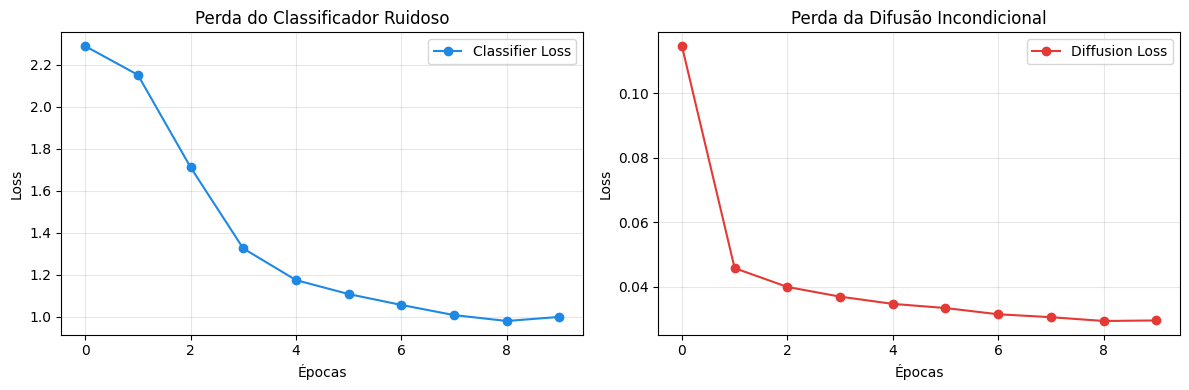

In [104]:
# Plotar curvas de treinamento do Classifier Guidance
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(c_losses, color="#1e88e5", marker='o', label="Classifier Loss")
plt.title("Perda do Classificador Ruidoso")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(u_losses, color="#e53935", marker='o', label="Diffusion Loss")
plt.title("Perda da Difusão Incondicional")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Amostragem e Inferência

Com o classificador e o modelo incondicional treinados, podemos amostrar novos dígitos manuscritos. A função de amostragem calcula o gradiente da probabilidade da classe desejada $y$ em relação à imagem intermediária $x_t$ e usa isso para empurrar a trajetória reversa em direção a imagens que se parecem com o dígito $y$.

In [105]:
@torch.enable_grad()
def p_sample_classifier_guidance(model, classifier, y_target, guidance_scale=1.0, num_samples=8):
    model.eval()
    classifier.eval()
    
    # Iniciar com ruído branco puro
    x = torch.randn(num_samples, 1, 32, 32, device=device)
    
    for t in reversed(range(n_steps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        
        # Habilitar gradientes para a imagem intermediária x
        x_in = x.detach().requires_grad_(True)
        
        # Prever ruído usando o modelo incondicional (sem gradientes do modelo)
        with torch.no_grad():
            eps_uncond = model(x_in, t_tensor)
            
        # Calcular os logits do classificador e sua log-probabilidade
        logits = classifier(x_in, t_tensor)
        log_probs = torch.log_softmax(logits, dim=-1)
        
        # Obter a log-probabilidade para a classe-alvo y_target
        target_log_probs = log_probs[torch.arange(num_samples), y_target]
        
        # Calcular o gradiente da log-probabilidade em relação a x_in
        grad = torch.autograd.grad(target_log_probs.sum(), x_in)[0]
        
        # Modificar a predição de ruído com a orientação do classificador
        sqrt_oma = sqrt_one_minus_alphas_cumprod[t]
        eps = eps_uncond - sqrt_oma * guidance_scale * grad
        
        # Coeficientes para o passo reverso
        a = alphas[t]
        b = betas[t]
        
        mean = (x - b * eps / sqrt_oma) / torch.sqrt(a)
        
        if t == 0:
            x = mean
        else:
            x = mean + torch.sqrt(posterior_variance[t]) * torch.randn_like(x)
            
    return x

Gerando dígitos para escala s = 0.0...
Gerando dígitos para escala s = 1.0...
Gerando dígitos para escala s = 2.0...
Gerando dígitos para escala s = 5.0...
Gerando dígitos para escala s = 10.0...


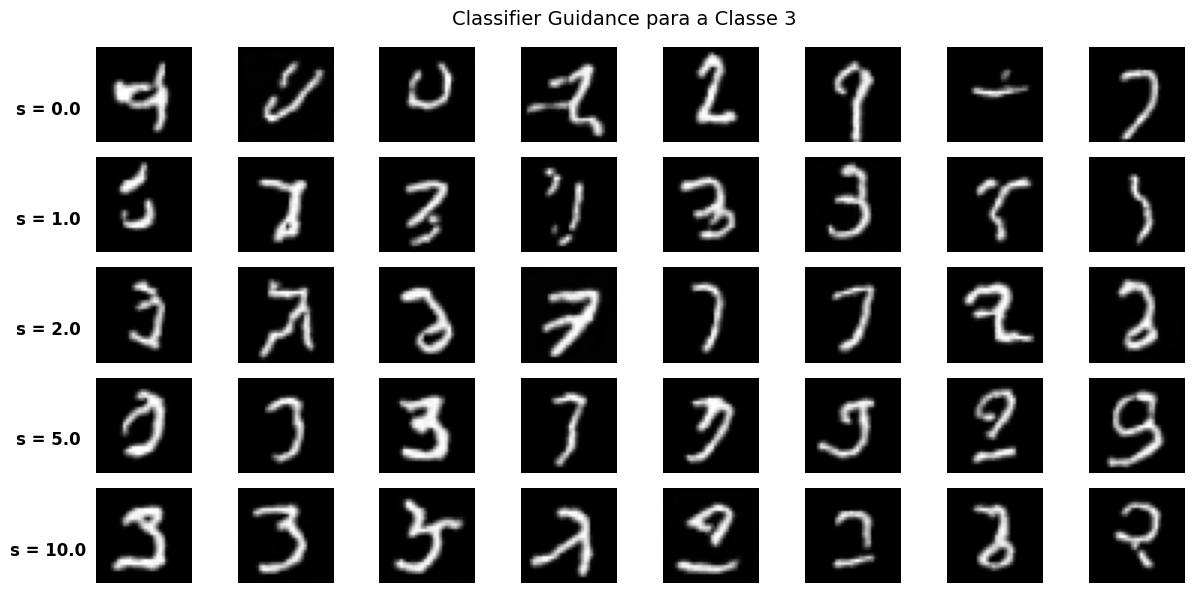

In [ ]:
# Gerar imagens para o dígito 3 usando diferentes escalas de orientação
y_target = 3
scales_to_test = [0.0, 1.0, 2.0, 5.0, 10.0]

fig, axs = plt.subplots(len(scales_to_test), 8, figsize=(12, 6))

for row_idx, scale in enumerate(scales_to_test):
    print(f"Gerando dígitos para escala s = {scale}...")
    samples = p_sample_classifier_guidance(uncond_model, classifier, y_target=y_target, guidance_scale=scale, num_samples=8)
    samples = (samples + 1.0) / 2.0  # Desnormalizar de [-1, 1] para [0, 1]
    samples = torch.clamp(samples, 0.0, 1.0).cpu().numpy().reshape(8, 32, 32)
    
    for col_idx in range(8):
        ax = axs[row_idx, col_idx]
        ax.imshow(samples[col_idx], cmap="gray")
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"s = {scale}", x=-0.5, y=0.2, fontsize=12, fontweight="bold")

plt.suptitle(f"Classifier Guidance para a Classe {y_target}", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## Classifier-Free Guidance (CFG)

O método Classifier-Free Guidance (CFG) evita o treinamento de um classificador separado. Em vez disso, treinamos um único modelo de difusão condicional $\epsilon_\theta(x_t, t, y)$ que também pode atuar incondicionalmente ao receber uma condição nula $\emptyset$.

Durante o treinamento, a condição $y$ é substituída por $\emptyset$ com probabilidade constante $p_{uncond}$ (ex: $15\%$). Durante a amostragem, realizamos uma extrapolação linear entre as predições condicional e incondicional:

$$\tilde{\epsilon}_\theta(x_t, t, y) = \epsilon_\theta(x_t, t, \emptyset) + s \left( \epsilon_\theta(x_t, t, y) - \epsilon_\theta(x_t, t, \emptyset) \right)$$

Onde $s \ge 1$ é a escala de guidance. Para $s=1$, temos a geração condicional clássica; para $s > 1$, enfatizamos os aspectos e detalhes visuais da classe condicionadora.

### Arquitetura do Modelo

A arquitetura do **Modelo de Difusão Condicional** (`ConditionalUNet`) é semelhante ao modelo incondicional, mas agora adicionamos uma camada de embedding (`nn.Embedding`) para mapear os rótulos de classe $0$ a $9$. O índice $10$ é reservado para a classe incondicional/nula $\emptyset$. O embedding de classe e o embedding temporal são somados e injetados na rede.

In [107]:
class ConditionalUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, hidden_dim=48, num_classes=10):
        super().__init__()

        time_dim = hidden_dim * 4
        self.null_class = num_classes

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(hidden_dim),
            nn.Linear(hidden_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.class_mlp = nn.Sequential(
            nn.Embedding(num_classes + 1, time_dim),
            nn.Linear(time_dim, time_dim),
            nn.GELU(),
            nn.Linear(time_dim, time_dim),
        )

        self.init_conv = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.down1 = ResBlock(hidden_dim, hidden_dim, time_dim)
        self.downsample1 = Downsample(hidden_dim)

        self.down2 = ResBlock(hidden_dim, hidden_dim * 2, time_dim)
        self.downsample2 = Downsample(hidden_dim * 2)

        self.mid1 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)
        self.mid2 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)
        self.mid3 = ResBlock(hidden_dim * 2, hidden_dim * 2, time_dim)

        self.upsample2 = Upsample(hidden_dim * 2)
        self.up2 = ResBlock(hidden_dim * 4, hidden_dim, time_dim)

        self.upsample1 = Upsample(hidden_dim)
        self.up1 = ResBlock(hidden_dim * 2, hidden_dim, time_dim)

        self.out = nn.Conv2d(hidden_dim, out_channels, 1)

    def forward(self, x, t, y):
        emb = self.time_mlp(t) + self.class_mlp(y)

        x = self.init_conv(x)

        h1 = self.down1(x, emb)       # 32x32
        x = self.downsample1(h1)      # 16x16

        h2 = self.down2(x, emb)       # 16x16
        x = self.downsample2(h2)      # 8x8

        x = self.mid1(x, emb)
        x = self.mid2(x, emb)
        x = self.mid3(x, emb)

        x = self.upsample2(x)         # 16x16
        x = torch.cat([x, h2], dim=1)
        x = self.up2(x, emb)

        x = self.upsample1(x)         # 32x32
        x = torch.cat([x, h1], dim=1)
        x = self.up1(x, emb)

        return self.out(x)

### Treinamento

Durante o treinamento do modelo condicional, aplicamos **Label Dropout** com probabilidade de $15\%$. Ou seja, para cada imagem do batch, há $15\%$ de chance de substituirmos o rótulo original $y$ pelo índice $10$ (classe nula $\emptyset$). Isso força o modelo a aprender a se comportar tanto de maneira condicional quanto incondicional.

In [108]:
# Instanciar modelo condicional, otimizador e função de perda
cond_model = ConditionalUNet().to(device)
optimizer_cond = optim.AdamW(cond_model.parameters(), lr=1e-3)
criterion_cond = nn.MSELoss()

In [109]:
# Treinamento do Modelo Condicional (10 épocas)
epochs_cond = 10
cond_losses = []

print("Iniciando treinamento do Modelo Condicional (CFG)...")
cond_model.train()
for epoch in range(epochs_cond):
    epoch_loss = 0
    progress_bar = tqdm(train_dataloader, desc=f"Difusão Condicional - Época {epoch+1}/{epochs_cond}")
    for imgs, labels in progress_bar:
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Aplicar Label Dropout de 15%
        mask = torch.rand(labels.shape, device=device) < 0.15
        labels_cond = labels.clone()
        labels_cond[mask] = 10  # índice 10 representa a classe nula
        
        # Amostrar t e ruído
        t = torch.randint(0, n_steps, (imgs.size(0),), device=device).long()
        noise = torch.randn_like(imgs)
        x_t = q_sample(imgs, t, noise)
        
        # Otimização
        optimizer_cond.zero_grad()
        pred_noise = cond_model(x_t, t, labels_cond)
        loss = criterion_cond(pred_noise, noise)
        loss.backward()
        optimizer_cond.step()
        
        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=loss.item())
        
    cond_losses.append(epoch_loss / len(train_dataloader))

Iniciando treinamento do Modelo Condicional (CFG)...


Difusão Condicional - Época 10/10: 100%|██████████| 78/78 [00:06<00:00, 12.51it/s, loss=0.0274]


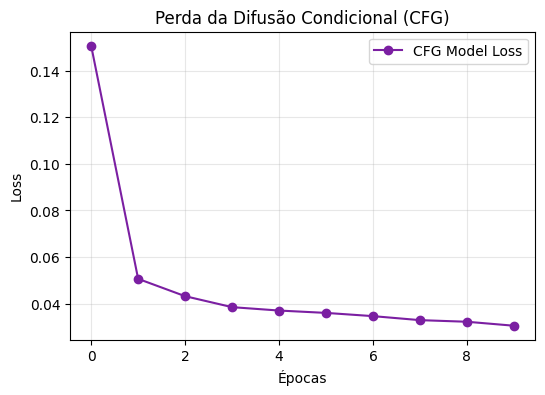

In [110]:
# Plotar curva de perda para o modelo condicional (CFG)
plt.figure(figsize=(6, 4))
plt.plot(cond_losses, color="#7b1fa2", marker='o', label="CFG Model Loss")
plt.title("Perda da Difusão Condicional (CFG)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### Amostragem e Inferência

Na amostragem com Classifier-Free Guidance, computamos a predição condicional $\epsilon_\theta(x_t, t, y)$ e a incondicional $\epsilon_\theta(x_t, t, \emptyset)$ em cada passo de tempo. O ruído final utilizado no passo reverso é a combinação linear dessas duas predições controlada pela escala $s$.

In [111]:
@torch.no_grad()
def p_sample_cfg(model, y_target, guidance_scale=1.0, num_samples=8):
    model.eval()
    
    # Iniciar com ruído branco puro
    x = torch.randn(num_samples, 1, 32, 32, device=device)
    
    # Rótulo condicional e rótulo incondicional (10)
    y_cond = torch.full((num_samples,), y_target, dtype=torch.long, device=device)
    y_uncond = torch.full((num_samples,), 10, dtype=torch.long, device=device)
    
    for t in reversed(range(n_steps)):
        t_tensor = torch.full((num_samples,), t, device=device, dtype=torch.long)
        
        # Predição de ruído condicional e incondicional
        eps_cond = model(x, t_tensor, y_cond)
        eps_uncond = model(x, t_tensor, y_uncond)
        
        # Combinar as predições usando a escala de guidance s
        eps = eps_uncond + guidance_scale * (eps_cond - eps_uncond)
        
        # Coeficientes para o passo reverso
        a = alphas[t]
        b = betas[t]
        sqrt_oma = sqrt_one_minus_alphas_cumprod[t]
        
        mean = (x - b * eps / sqrt_oma) / torch.sqrt(a)
        
        if t == 0:
            x = mean
        else:
            x = mean + torch.sqrt(posterior_variance[t]) * torch.randn_like(x)
            
    return x

Gerando dígitos com CFG escala s = 0.0...
Gerando dígitos com CFG escala s = 1.5...
Gerando dígitos com CFG escala s = 3.0...
Gerando dígitos com CFG escala s = 5.0...
Gerando dígitos com CFG escala s = 10.0...


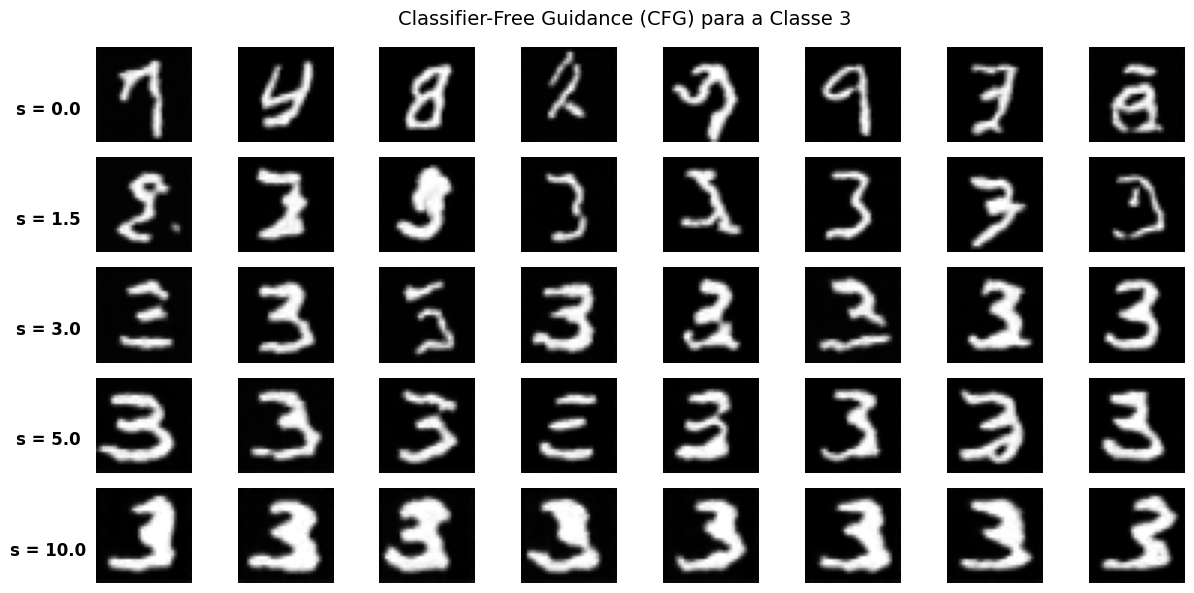

In [112]:
# Gerar imagens para o dígito 3 usando Classifier-Free Guidance
y_target = 3
cfg_scales = [0.0, 1.5, 3.0, 5.0, 10.0]

fig, axs = plt.subplots(len(cfg_scales), 8, figsize=(12, 6))

for row_idx, scale in enumerate(cfg_scales):
    print(f"Gerando dígitos com CFG escala s = {scale}...")
    samples = p_sample_cfg(cond_model, y_target=y_target, guidance_scale=scale, num_samples=8)
    samples = (samples + 1.0) / 2.0  # Desnormalizar para [0, 1]
    samples = torch.clamp(samples, 0.0, 1.0).cpu().numpy().reshape(8, 32, 32)
    
    for col_idx in range(8):
        ax = axs[row_idx, col_idx]
        ax.imshow(samples[col_idx], cmap="gray")
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(f"s = {scale}", x=-0.5, y=0.2, fontsize=12, fontweight="bold")

plt.suptitle(f"Classifier-Free Guidance (CFG) para a Classe {y_target}", fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

## Exercícios

### Exercício 1
Experimente gerar outros dígitos manuscritos (como `0`, `7` ou `9`) utilizando ambos os métodos (Classifier Guidance e CFG) com diferentes escalas de orientação ($s$). Observe o que acontece com a qualidade geométrica das formas e relate como os métodos diferem ao destacar os traços característicos de cada dígito.

### Exercício 2
No treinamento do modelo condicional para CFG, utilizamos um dropout de rótulo (*label dropout*) de $15\%$. Modifique a célula de treinamento para usar um valor de dropout diferente (por exemplo, $5\%$ ou $50\%$) e execute o treinamento novamente. Explique como a taxa de dropout afeta a capacidade do modelo de gerar amostras condicionais de boa qualidade.

### Exercício 3
Utilize escalas de orientação muito altas (como $s = 15$ ou $s = 20$) e observe os resultados. Por que a imagem gerada se torna superexposta ou saturada? Quais técnicas poderiam ser usadas para mitigar esse problema?